In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
from tqdm import tqdm

device = 'cuda' if torch.cuda.is_available() else 'cpu'

/home/renan-florencio/miniconda3/envs/autoencoder/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Download latest version
path = kagglehub.dataset_download("nitishabharathi/scene-classification")
TRAIN_PATH = path + "/train-scene classification/train/"

In [4]:
def load_data(path):
    names = []
    for img in os.listdir(path):
        names.append(os.path.join(path, img))
    
    df = pd.DataFrame({
        "filename" : names
    })
    return df

In [5]:
df = load_data(TRAIN_PATH)
df.head(), df.shape

(                                            filename
 0  /home/renan-florencio/.cache/kagglehub/dataset...
 1  /home/renan-florencio/.cache/kagglehub/dataset...
 2  /home/renan-florencio/.cache/kagglehub/dataset...
 3  /home/renan-florencio/.cache/kagglehub/dataset...
 4  /home/renan-florencio/.cache/kagglehub/dataset...,
 (24335, 1))

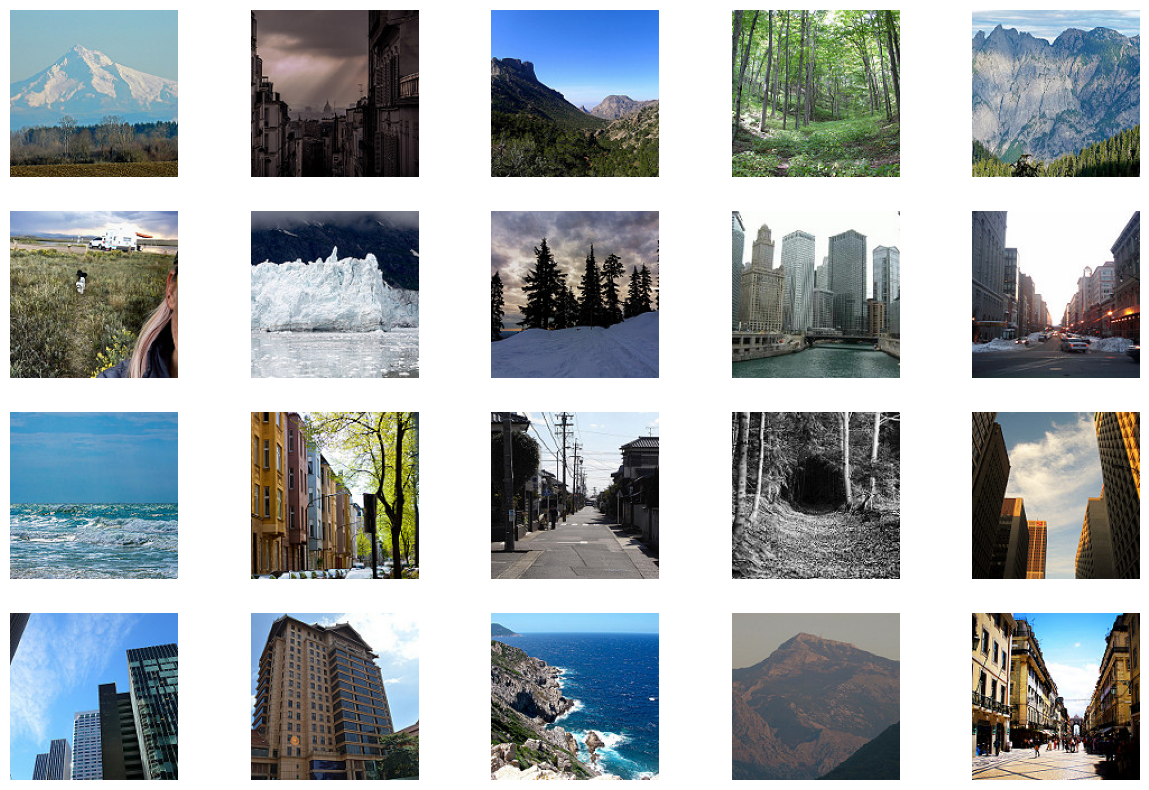

In [6]:
plt.figure(figsize=(15, 10))
for i, img in enumerate(df.sample(20)['filename']):
    plt.subplot(4, 5, i + 1)
    img = plt.imread(img)
    plt.imshow(img)
    plt.axis('off')
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
df_train, df_val = train_test_split(df, test_size=0.2)

In [8]:
df_train.shape, df_val.shape

((19468, 1), (4867, 1))

# Building the Dataset

In [9]:
# This allows us to resize, normalize and turn the images into tenosrs
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((64, 64)),
    transforms.Normalize(mean = 0, std = 1),
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((64, 64)),
    transforms.Normalize(mean = 0, std = 1),
])

Since this dataset is composed of images, we need to define a class. The df from Pandas will not work.

In [10]:
class DatasetBuilder:
    def __init__(self, df, transform) -> None:
        self.df = df
        self.n_samples = len(self.df)
        self.transform = transform

    def __len__(self):
        return self.n_samples
    
    def __getitem__(self, idx):
        img = plt.imread(self.df.iloc[idx, 0])
        if self.transform:
            img = self.transform(img)
        return img

In [11]:
train_dataset = DatasetBuilder(df_train, train_transform)
val_dataset = DatasetBuilder(df_val, val_transform)

In [12]:
len(train_dataset)

19468

## For now, let's skip Data Augmentation

We'll base our architecture on the UNet

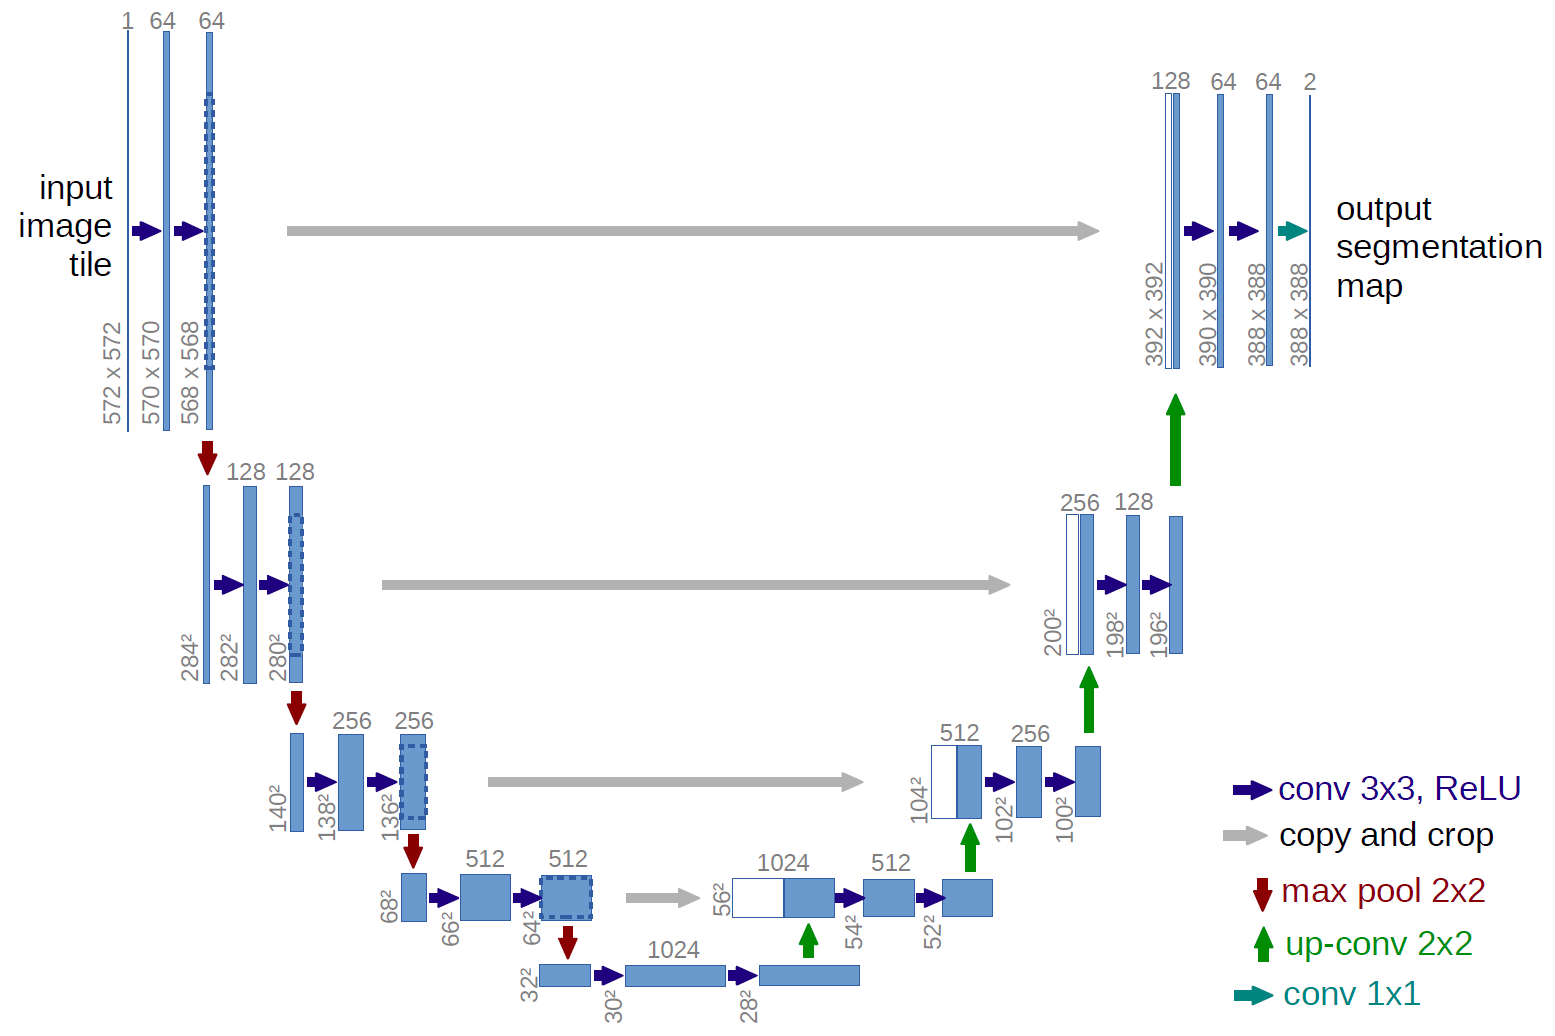

With smaller dimensions

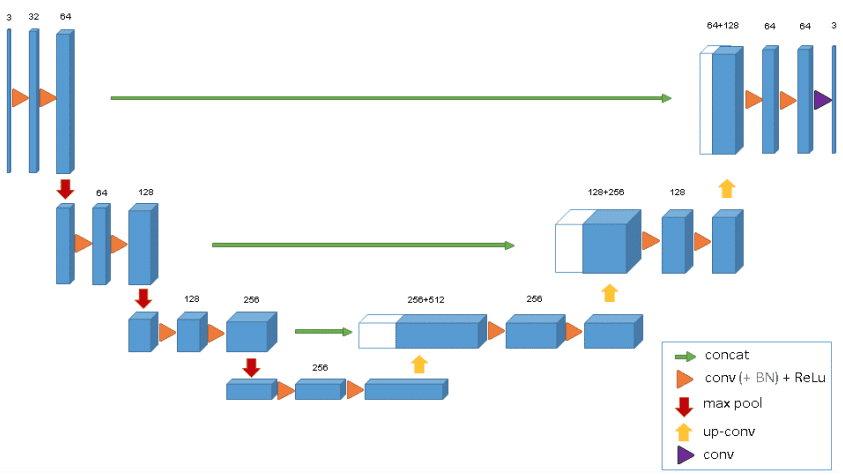

In [13]:
class stdEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.block1 = self.block(1, 32, 64, 3, 1, 1)
        self.block2 = self.block(64, 64, 128, 3, 1, 1)
        self.block3 = self.block(128, 128, 256, 3, 1, 1)
        self.block4 = self.block(256, 256, 512, 3, 1, 1)
        self.maxpool = nn.MaxPool2d(kernel_size=2)

    def block(self, in_dim, mid_dim, out_dim, kernel_size, stride, padding):
        layers = [
            nn.Conv2d(in_dim, mid_dim, kernel_size=kernel_size, stride=stride, padding=padding),
            nn.BatchNorm2d(mid_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Conv2d(mid_dim, out_dim, kernel_size=kernel_size, stride=stride, padding=padding),
            nn.BatchNorm2d(out_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
        ]
        return nn.Sequential(*layers)
    
    def forward(self, x):
        # x <- (1, 128, 128) grayscale (1) 128 x 128 image
        h1 = self.block1(x) # (64, 128, 128) 64 channels, 64x64 image
        x = self.maxpool(h1) # (64, 64, 64)
        h2 = self.block2(x) # (128, 32, 32)
        x = self.maxpool(h2)
        h3 = self.block3(x) # (256, 16, 16)
        x = self.maxpool(h3)
        h4 = self.block4(x)  # (512, 16, 16) has no maxpolling
        
        return [h1, h2, h3, h4]

In [14]:
enc = stdEncoder()
ex = torch.randn(1, 1, 64, 64)
ex_out = enc(ex)
for i in ex_out:        # ← ex_out, not enc(ex)!
    print(i.shape)

torch.Size([1, 64, 64, 64])
torch.Size([1, 128, 32, 32])
torch.Size([1, 256, 16, 16])
torch.Size([1, 512, 8, 8])


In [15]:
class stdDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.up1 = nn.ConvTranspose2d(512, 512, kernel_size=2, stride=2)
        self.block1 = self.block(256+512, 256, 256, 3, 1, 1)
        self.up2 = nn.ConvTranspose2d(256, 256, kernel_size=2, stride=2)
        self.block2 = self.block(128+256, 128, 128, 3, 1, 1)
        self.up3 = nn.ConvTranspose2d(128, 128, kernel_size=2, stride=2)
        self.block3 = self.block(64+128, 64, 64, 3, 1, 1)
        self.out = nn.Conv2d(64, 3, 3, 1, 1)

    def block(self, in_dim, mid_dim, out_dim, kernel_size, stride, padding, bottleneck=False):
        layers = [
            nn.Conv2d(in_dim, mid_dim, kernel_size=kernel_size, stride=stride, padding=padding),
            nn.BatchNorm2d(mid_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Conv2d(mid_dim, out_dim, kernel_size=kernel_size, stride=stride, padding=padding),
            nn.BatchNorm2d(out_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
        ]
        return nn.Sequential(*layers)
    
    def forward(self, h):
        x = h[-1] # (512, 16, 16) 

        x = self.up1(x) # (512, 32, 32)
        x = torch.concat([x, h[-2]], dim=1) # (256+512, 32, 32)
        x = self.block1(x) # (256, 32, 32)

        x = self.up2(x) # (256, 64, 64)
        x = torch.concat([x, h[-3]], dim=1) # (128+256, 64, 64)
        x = self.block2(x) # (128, 64, 64)

        x = self.up3(x) # (128, 128, 128)
        x = torch.concat([x, h[-4]], dim=1) # (64+128, 128, 128)
        x = self.block3(x) # (64, 128, 128)

        x = self.out(x)
        
        return x

In [16]:
encoder = stdEncoder()
decoder = stdDecoder()
ex = torch.randn(1, 1, 128, 128)
h = encoder(ex)
out = decoder(h)
print(out.shape)  # should be torch.Size([1, 3, 128, 128])

torch.Size([1, 3, 128, 128])


In [ ]:
class Net(nn.Module):
    def __init__(self, **kwargs):
        super().__init__()
        train_dataset = kwargs["train_dataset"]
        val_dataset = kwargs["val_dataset"]
        self.batch_size = kwargs["batch_size"]
        self.train_loader = DataLoader(train_dataset, batch_size = self.batch_size, shuffle = True)
        self.val_loader = DataLoader(val_dataset, batch_size=self.batch_size)

        self.lr = 5e-4
        
        self.encoder = encoder
        self.decoder = decoder

        self.history = {"t_loss" : [], "v_loss": []}
        self.train_batches = np.ceil(len(train_dataset)/self.batch_size)
        self.val_batches = np.ceil(len(val_dataset)/self.batch_size)

        self.grayscale = transforms.Grayscale(1)

        self.loss_fxn = nn.MSELoss()
        self.optimizer = torch.optim.Adam(self.parameters(), lr = self.lr)
    
    def forward(self, x):
        x = self.grayscale(x)
        h = self.encoder(x)
        h = self.decoder(h)
        return h
    
    def training_step(self, X): # Only one X, since self supervised
        pred = self.forward(X)
        loss = self.loss_fxn(pred, X)
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss
    
    def validation_step(self, X):
        with torch.no_grad():
            pred = self.forward(X)
            loss = self.loss_fxn(pred, X)

            return loss

    def fit(self, epochs=5):  # ← rename train to fit
        for epoch in tqdm(range(epochs)):
            self.train()  # ← now you can still call nn.Module's train() to set training mode
            epoch_tl = 0
            epoch_vl = 0
            for X in tqdm(self.train_loader):
                X = X.to(device)
                epoch_tl += self.training_step(X)
            
            self.eval()   # ← set eval mode for validation
            epoch_vl = 0
            for X in tqdm(self.val_loader):
                X = X.to(device)
                epoch_vl += self.validation_step(X)
            
            epoch_tl /= self.train_batches  # ← also use train_batches, not batch_size
            epoch_vl /= self.val_batches
            self.history["t_loss"].append(epoch_tl.item())
            self.history["v_loss"].append(epoch_vl.item())
            print(f"[Epoch: {epoch+1}] [Train loss: {epoch_tl:.4f}] [Val loss: {epoch_vl:.4f}]")

In [19]:
args = {
    "train_dataset" : train_dataset,
    "val_dataset" : val_dataset,
    "batch_size" : 8,
}
model = Net(**args).to(device)
model

Net(
  (encoder): stdEncoder(
    (block1): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.1, inplace=False)
    )
    (block2): Sequential(
      (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.1, inplace=False)
   

In [21]:
x = torch.randn(16, 1, 64, 64).to(device)
print(model(x).shape)
del(x)

torch.Size([16, 3, 64, 64])


In [22]:
model.fit(epochs = 1)

  0%|          | 0/1 [00:00<?, ?it/s]/home/renan-florencio/miniconda3/envs/autoencoder/lib/python3.11/site-packages/torchvision/transforms/functional.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  img = torch.from_numpy(pic.transpose((2, 0, 1))).contiguous()
  0%|          | 0/1 [20:35<?, ?it/s]


RuntimeError: stack expects each tensor to be equal size, but got [3, 64, 64] at entry 0 and [1, 64, 64] at entry 3